In [33]:
import seaborn as sns
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import numpy as np

df = sns.load_dataset("titanic")
df.head()
# keep only these 7 features
df = df[['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare']]

# description of columns
# survived: 0 = No, 1 = Yes
# pclass: 1 = 1st, 2 = 2nd, 3 = 3rd; class of the ticket
# age: age in years
# sibsp: # of siblings / spouses aboard the Titanic
# parch: # of parents / children aboard the Titanic
# fare: passenger fare

# missing values
df['age'] = df['age'].fillna(df['age'].median())


# one hot conversion for categorical variables
# drop_first = True; 2 hi category hain , male and female. Either male = 1 and female = 0 or vice versa.
# notice that the sum of the two columns will always be 1. To do column kyon rakhna hai jab ek hi column se kaam chal jaaye. So, we drop one column.
df = pd.get_dummies(df, columns=['sex'], drop_first=True, dtype=float) 
df.head()


# ----------------------------
# Split the dataframe
# ----------------------------

train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["survived"]
)


# standard scaler
scaler = StandardScaler()
# apply scaler to the features
continuous = ['age', 'fare']

scaler = StandardScaler()
train_df[continuous] = scaler.fit_transform(train_df[continuous])
test_df[continuous] = scaler.transform(test_df[continuous])

train_df.head()
test_df.head()

,survived,pclass,age,sibsp,parch,fare,sex_male
565,0,3,-0.419170,2,0,-0.159704,1.0
160,0,3,1.116290,0,1,-0.327324,1.0
553,1,3,-0.572716,0,0,-0.512122,1.0
860,0,3,0.885971,2,0,-0.368795,1.0
241,1,3,-0.112078,1,0,-0.339817,0.0


In [34]:
import torch

X = torch.tensor(train_df.drop('survived', axis=1).values, dtype=torch.float32)
y = torch.tensor(train_df['survived'].values, dtype=torch.float32)
Xtest = torch.tensor(test_df.drop('survived', axis=1).values, dtype=torch.float32)
ytest = torch.tensor(test_df['survived'].values, dtype=torch.float32)
print(X.shape, y.shape)
y = y.view(-1, 1)
ytest = ytest.view(-1, 1)
print(X.shape, y.shape)
print(Xtest.shape, ytest.shape)

# X, y

torch.Size([712, 6]) torch.Size([712])
torch.Size([712, 6]) torch.Size([712, 1])
torch.Size([179, 6]) torch.Size([179, 1])


In [ ]:
class TitanicModel_logregress(torch.nn.Module):
    def __init__(self):
        super(TitanicModel_logregress, self).__init__()
        self.fc1 = torch.nn.Linear(6, 1)  # 6 input features, 1 output feature
        # self.fc2 = torch.nn.Linear(16, 8) # hidden layer with 8 neurons
        # self.fc3 = torch.nn.Linear(16, 1)  # 16 input features, 1 output feature
        self.relu = torch.nn.ReLU()
        self.sigmoid = torch.nn.Sigmoid()

    def forward(self, x):
        x = self.fc1(x)
        # x = self.relu(x)
        # x = self.fc2(x)
        # x = self.relu(x)
        # x = self.fc3(x)
        # x = self.sigmoid(x)
        return x
    

class TitanicModel(torch.nn.Module):
    def __init__(self):
        super(TitanicModel, self).__init__()
        self.fc1 = torch.nn.Linear(6, 16)  # 6 input features, 16 output features
        self.fc2 = torch.nn.Linear(16, 8) # hidden layer with 8 neurons
        self.fc3 = torch.nn.Linear(8, 1)  # 8 input features, 1 output feature
        self.relu = torch.nn.ReLU()

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.relu(x)
        x = self.fc3(x)
        return x



model = TitanicModel()
criterion = torch.nn.BCEWithLogitsLoss()  # binary cross entropy loss with logits
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=3e-3)  # Adam optimizer with weight decay

train_losses = []
test_losses = []



In [36]:
from torchinfo import summary
print(summary(model, input_size=(X.shape[0], X.shape[1])))

Layer (type:depth-idx)                   Output Shape              Param #
TitanicModel                             [712, 1]                  --
├─Linear: 1-1                            [712, 16]                 112
├─ReLU: 1-2                              [712, 16]                 --
├─Linear: 1-3                            [712, 8]                  136
├─ReLU: 1-4                              [712, 8]                  --
├─Linear: 1-5                            [712, 1]                  9
Total params: 257
Trainable params: 257
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.18
Input size (MB): 0.02
Forward/backward pass size (MB): 0.14
Params size (MB): 0.00
Estimated Total Size (MB): 0.16


In [37]:
epochs = 3000

for epoch in range(epochs):
    # forward pass
    y_pred = model(X)
    loss = criterion(y_pred, y)
    train_losses.append(loss.item())
    model.eval()
    with torch.no_grad():
        test_loss = criterion(model(Xtest), ytest)
        test_losses.append(test_loss.item())
    model.train()
    # backward pass
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch+1) % 1000 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}')

Epoch [1000/3000], Loss: 0.3854
Epoch [2000/3000], Loss: 0.3670
Epoch [3000/3000], Loss: 0.3556


In [38]:
# accuracy on test set

X_test = torch.tensor(test_df.drop('survived', axis=1).values, dtype=torch.float32)
y_test = torch.tensor(test_df['survived'].values, dtype=torch.float32)
y_test = y_test.view(-1, 1)
model.eval()  # set the model to evaluation mode
with torch.no_grad():
    y_pred = model(X_test)
    y_pred = torch.sigmoid(y_pred)
    y_pred_cls = y_pred.round()
    acc = y_pred_cls.eq(y_test).sum() / float(y_test.shape[0])
    print(f'Accuracy: {acc:.4f}')

# accuracy on training set
with torch.no_grad():
    y_pred = model(X)
    y_pred = torch.sigmoid(y_pred)
    y_pred_cls = y_pred.round()
    acc = y_pred_cls.eq(y).sum() / float(y.shape[0])
    print(f'Training Accuracy: {acc:.4f}')

Accuracy: 0.8212
Training Accuracy: 0.8539


(0.0, 1.0)

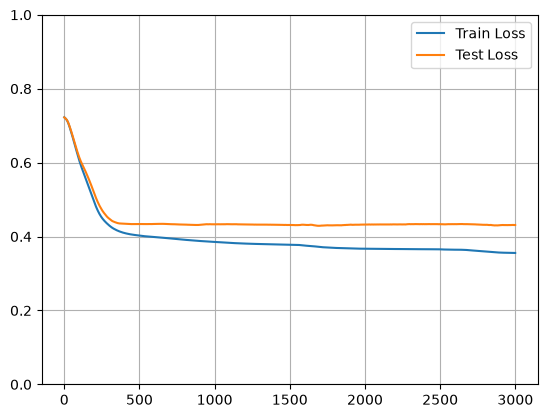

In [39]:
import matplotlib.pyplot as plt
plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Test Loss')
plt.legend()
plt.grid(True)
plt.ylim(0, 1)

[[405  34]
 [ 70 203]]


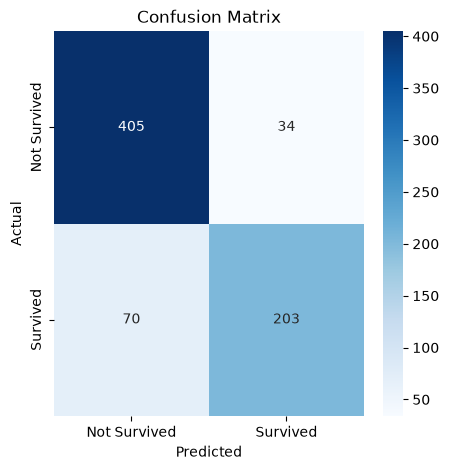

In [40]:
# confusion matrix

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

with torch.no_grad():
    y_pred = model(X)
    y_pred = torch.sigmoid(y_pred)
    y_pred_cls = y_pred.round()
    cm = confusion_matrix(y, y_pred_cls)
    print(cm)

    plt.figure(figsize=(5, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Survived', 'Survived'], yticklabels=['Not Survived', 'Survived'])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()